# bAsedPL

bAsedPL ("Based-array APL") is an APL-derived array language, borrowing ideas from J and BQN, with an emphasis on simple, consistent notation. It is implemented in Rust, with a native executable, Jupyter kernel and Python API.

For APL users, the main choices are:

- [Based arrays](rules.qmd#arrays-nesting-and-fill), as in BQN: numbers, characters and functions are atoms; enclosure always adds a layer.
- **Brackets write lists**, and spaces group: `[a b c]` is a vector, and `a+b × c+d` is `(a+b)×(c+d)`. An array next to an argument selects from it: `v 0` is the first item.
- **Leading-axis broadcasting**, including unit-axis expansion, plus string keys and names on axes.
- **Exact integers and rationals** alongside approximate real and complex numbers.
- Dfns, trains and operators, with additions such as Under, iteration histories, windows and function arrays.

Positions and axes count from 0, as in BQN and Python. Approximate comparisons use tolerance `1E¯14`. See the [glyph reference](glyphs.qmd) for Dyalog differences and the [language rules](rules.qmd) for the array model.

## Install and try it

```sh
pip install basedpl
bapl
```

At the prompt, define a mean and apply it:

In [ ]:
avg←+/÷≢
avg 2 4 9

5

Use `bapl -e 'avg←+/÷≢ ⋄ avg 2 4 9'` for a shell command. The [command-line guide](cli.qmd) covers source files and pipes.

## Interactive use

In the **REPL**, type a backtick followed by a glyph name: `` `iota `` becomes `⍳` when you press Tab or type a non-letter. Abbreviations and Alt-key shortcuts are available. `]help +` shows help; `]box on -style=max -trains=tree -fns=on` enables boxed arrays and function trees. See [REPL](repl.qmd) and [Keyboard](keyboard.qmd).

In **Jupyter**, select the installed **bAsedPL** kernel. Cells share definitions and support completion, Shift-Tab help and interruption. You can also use `%%apl` cells in a Python notebook. See [Using bAsedPL notebooks](notebooks.ipynb).

## New to APL?

APL is a language built around operations on whole arrays and notation for combining functions. Here is a taste of that style in bAsedPL.

Numbers separated by spaces form a vector. Arithmetic applies to every element:

In [ ]:
10+1 2 3

11 12 13

Operators modify or combine functions. Reduce (`/`) turns addition into summation. `⍳10` generates 0…9:

In [ ]:
+/⍳10

45

Functions can also be combined without naming their arguments. In `avg←+/÷≢`, sum (`+/`) divided by tally (`≢`) defines the mean:

In [ ]:
avg 1 2 3 4

2.5

To see how these ideas express an algorithm, start from “a prime has exactly two positive divisors”. Form all remainders of 1 to 50 (`|⌝⍨1+⍳50`), count the zeros down each column (`+⌿0=`), and find the positions (`⍸`) whose count is two. Positions count from 0, so `1+` turns them back into numbers:

In [ ]:
1+⍸2=+⌿0=|⌝⍨1+⍳50

2 3 5 7 11 13 17 19 23 29 31 37 41 43 47

[Getting started](getting-started.ipynb#example-algorithms) builds this expression step by step, displaying the divisibility matrix along the way.

## What's distinctive?

### Numbers

Bare numbers are approximate. Use `x` for exact integers and `r` for exact fractions:

In [ ]:
1r3+1r6

1r2

Complex numbers use `j` between real and imaginary parts. Functions such as square root extend into the complex domain:

In [ ]:
√¯4

0j2

See [numbers](rules.qmd#numbers) for conversion and mixed arithmetic.

### Array literals and broadcasting

Write matrix rows directly in an array literal. Leading-axis agreement lets a vector supply one offset per row:

In [ ]:
m←[1 2 3 ⋄ 4 5 6]
m+10 20

11 12 13
24 25 26

See [array notation](glyphs/brackets.qmd) and [broadcasting](rules.qmd#agreement-and-pervasion).

### Keys and named axes

Axes can have names, and positions along them can have string keys. Describe the axes once, then select by key or reduce by axis name:

In [ ]:
axes←["city":["NY" "LA"] "month":["Jan" "Feb" "Mar"]]
sales←axes:[10 20 30 ⋄ 40 50 60]
"LA" "Feb"⌷sales
+/⍠"month" sales

50

["city":2]⍴["NY":60 "LA":150]

Keys and names travel with axes through operations such as transpose. Arithmetic aligns matching names and keys. See [Axis keys](keyed.qmd).

### Function operators

A list of counts keeps the history: one state for each count, where count 0 is the initial value. Here, double up to four times:

In [ ]:
2×⍣(⍳5) 1

1 2 4 8 16

Under (`⌾`) transforms the argument, applies a function, then reverses the transformation. Scale by ten, floor, and scale back to round down to tenths:

In [ ]:
⌊⌾(10×)1.25 2.78

1.2 2.7

Explore [iteration and inverses](glyphs/power.qmd), [Under](glyphs/under.qmd), [windows](glyphs/windows.qmd) and [function selection](glyphs/agenda.qmd).

### Mathematical tools

[Primes](glyphs/prime.qmd) and [factorisation](glyphs/factor.qmd) are built in:

In [ ]:
⨸360x

2ₓ 2ₓ 2ₓ 3ₓ 3ₓ 5ₓ

[Polynomials](glyphs/polynomial.qmd) support coefficients, roots and evaluation. Polynomial functions can be [differentiated](glyphs/derivative.qmd): for f(x) = 1 + 2x + 3x², f′(2) = 14.

In [ ]:
f←1x 2x 3x⊛ ⋄ f∂2x

14ₓ

[Probability distributions](distributions.ipynb) provide sampling, density, CDF and quantiles. Two fair coin tosses give these probabilities for 0, 1 and 2 heads:

In [ ]:
coin←•binomial 2 0.5
coin.density 0 1 2

0.25 0.5 0.25

[Matrix division](glyphs/domino.qmd) handles linear systems and least squares.

### Data and text

JSON objects become keyed arrays, with dot access to their fields:

In [ ]:
order←•json "{""price"":10.5,""qty"":2}"
order.price×order.qty

21

CSV headers likewise name column vectors. [Files, CSV and JSON](data.ipynb) covers reading, transforming and writing data. [Regex](regex.ipynb) supplies matching, captures and replacement through Rust's regex engine.

### Drawing

`•plot` draws charts from arrays. Keys label the axes and name the lines. See [Plots](plot.ipynb).

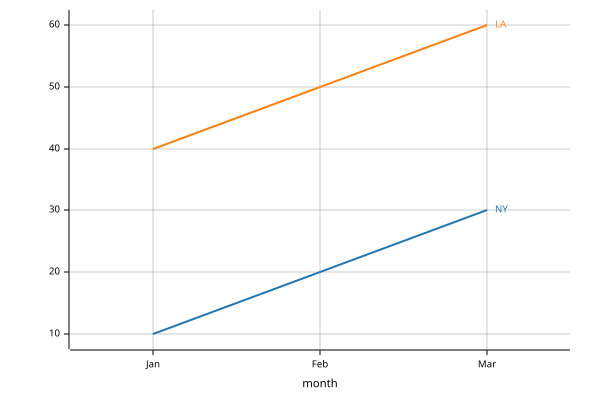

In [ ]:
["legend":"end"]•plot sales

Build SVG from element functions and keyed attributes. Notebooks display the picture directly. The same element trees serialize to XML. See [XML and SVG](xml.ipynb).

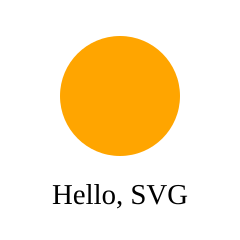

In [ ]:
circle←•element "circle"
text←•element "text"
c←["cx":50 "cy":40 "r":25 "fill":"orange"]circle ""
t←["x":50 "y":85 "text-anchor":"middle"]text "Hello, SVG"
["width":240 "height":240]•svg [c t]

## Python

APL functions are Python callables:

```python
from basedpl import fn

mean = fn('+/÷≢')
mean([1, 2, 3])
```

Arrays have `.py`, `.np` and `.df` conversions for Python values, NumPy and pandas. Functions also have Python names and composition operators. See the [Python tutorial](python.ipynb).

For other frontends, the [process interfaces](processes.qmd) provide JSON messages and interruptible workers. The [APL library](https://github.com/AnswerDotAI/basedpl/tree/main/lib) contains more algorithms, codecs, interpreters and puzzles. See [DEV.md](https://github.com/AnswerDotAI/basedpl/blob/main/DEV.md) for source installation and contributing.